# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [28]:
# Manipulasi Data
import pandas as pd
import numpy as np

# Visualisasi Data (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing dari Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [29]:
# Memuat dataset
df = pd.read_csv('Credit_Scoring_Bank.csv', sep=';')

# Menampilkan 5 baris pertama
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [30]:
# Mengecek struktur dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [31]:
# Mendeskripsikan
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [32]:
# 1. Mengecek Missing Values
display(df.isnull().sum().to_frame('Jumlah Missing Values'))

,Jumlah Missing Values
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [33]:
# 2. Mengecek Data Duplikat
display(pd.DataFrame({'Jumlah Baris Duplikat': [df.duplicated().sum()]}))

,Jumlah Baris Duplikat
0,0


In [34]:
# 3. Distribusi Kelas Target 'y'
display((df['y'].value_counts(normalize=True) * 100).to_frame('Persentase Distribusi (%)'))


,Persentase Distribusi (%)
y,
no,88.476001
yes,11.523999


/tmp/ipykernel_1508/3246159664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='viridis')


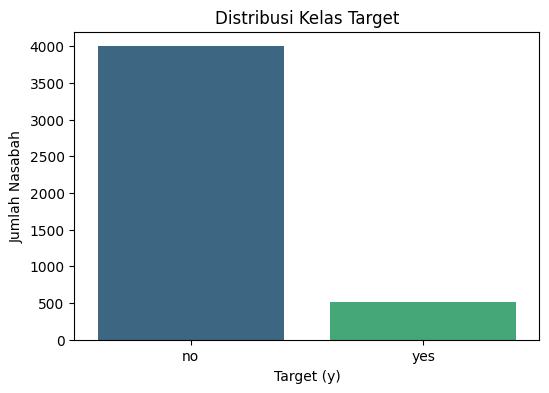

In [35]:
# 4. Visualisasi Distribusi
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', palette='viridis')
plt.title('Distribusi Kelas Target')
plt.xlabel('Target (y)')
plt.ylabel('Jumlah Nasabah')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kamu menggunakan data tidak terstruktur.

In [36]:
# Menghapus nilai kosong
df.dropna()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [37]:
# Menghapus duplikasi
df.drop_duplicates()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [38]:
# Penanganan Outlier (Metode IQR Capping)
outlier_cols = ['balance', 'duration']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Menentukan batas wajar
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    # Capping: Timpa nilai yang lewat batas dengan nilai batas maksimal/minimal
    df[col] = np.where(df[col] > batas_atas, batas_atas, df[col])
    df[col] = np.where(df[col] < batas_bawah, batas_bawah, df[col])

# Tampilkan hasil statistik baru untuk validasi
display(df[['balance', 'duration']].describe())

,balance,duration
count,4521.000000,4521.000000
mean,973.493696,241.785667
std,1240.356566,185.397346
min,-2047.500000,4.000000
25%,69.000000,104.000000
50%,444.000000,185.000000
75%,1480.000000,329.000000
max,3596.500000,666.500000


In [39]:
# Encoding data kategorikal
# Deteksi otomatis semua kolom yang tipe datanya teks (object)
cat_cols = df.select_dtypes(include=['object']).columns

# Panggil mesin encoder-nya
le = LabelEncoder()

# Ubah semua kolom teks tersebut jadi angka sekaligus pakai perulangan
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("[-] Encoding selesai. Semua teks telah menjadi angka.")
display(df.head())

[-] Encoding selesai. Semua teks telah menjadi angka.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,10,1,0,0,1787.0,0,0,0,19,10,79.0,1,-1,0,3,0
1,33,7,1,1,0,3596.5,1,1,0,11,8,220.0,1,339,4,0,0
2,35,4,2,2,0,1350.0,1,0,0,16,0,185.0,1,330,1,0,0
3,30,4,1,2,0,1476.0,1,1,2,3,6,199.0,4,-1,0,3,0
4,59,1,1,1,0,0.0,1,0,2,5,8,226.0,1,-1,0,3,0


In [40]:
# Normalisasi/standarisai fitur
# Memisahkan nama kolom target 'y' agar tidak ikut di-scale
fitur_cols = df.columns.drop('y')

# Memanggil mesin scaler
scaler = StandardScaler()

# Melakukan standarisasi HANYA pada kolom fitur
df[fitur_cols] = scaler.fit_transform(df[fitur_cols])

print("[-] Standarisasi selesai. Skala data telah diseragamkan.")
display(df.head())

[-] Standarisasi selesai. Skala data telah diseragamkan.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,-1.056270,1.716804,-0.246429,-1.644755,-0.130759,0.655937,-1.142051,-0.424756,-0.723642,0.374052,1.485414,-0.878134,-0.576829,-0.407218,-0.320413,0.444413,0
1,-0.772583,0.795246,-0.246429,-0.309038,-0.130759,2.114953,0.875617,2.354292,-0.723642,-0.596026,0.819288,-0.117521,-0.576829,2.989044,2.041734,-2.579961,0
2,-0.583458,-0.126313,1.421396,1.026680,-0.130759,0.303580,0.875617,-0.424756,-0.723642,0.010273,-1.845220,-0.306326,-0.576829,2.899143,0.270124,-2.579961,0
3,-1.056270,-0.126313,-0.246429,1.026680,-0.130759,0.405175,0.875617,2.354292,1.495133,-1.566105,0.153161,-0.230804,0.387967,-0.407218,-0.320413,0.444413,0
4,1.686036,-1.047871,-0.246429,-0.309038,-0.130759,-0.784937,0.875617,-0.424756,1.495133,-1.323585,0.819288,-0.085154,-0.576829,-0.407218,-0.320413,0.444413,0
